In [ ]:
    import pandas as pd

In [ ]:
import numpy as np 

##### LOADING THE CSV 


In [ ]:
# Load both fake and real news CSV files
fake_df = pd.read_csv(r"C:\Users\Saloni\Downloads\F_R_News\dataset\Fake.csv")

In [ ]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
real_df = pd.read_csv(r"C:\Users\Saloni\Downloads\F_R_News\dataset\True.csv")

In [ ]:
real_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


##### LABELING THE DATA 

In [ ]:
# add labels : 0 = fake , 1 = real
fake_df["label"] = 0
real_df["label"] = 1

In [ ]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
real_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


##### CONCATINATION OF TWO FILES 

In [ ]:
#we will going to concat the data 
news_df = pd.concat([fake_df, real_df], axis=0)

##### SHUFFLE THE DATA 

In [ ]:
# we will shuffle the dataset to mix up the data 
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
news_df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


##### REMOVING DUPLICATE

In [ ]:
#We will check the duplicate rows in the data
print("Total Duplicate Rows:",news_df.duplicated().sum())

Total Duplicate Rows: 209


In [ ]:
# we will remove the duplicate 
news_df = news_df.drop_duplicates()

In [ ]:
# we will again check the duplicate in the data after removal 
print("Total Duplicate Rows:",news_df.duplicated().sum())

Total Duplicate Rows: 0


In [ ]:
# we will check the size of our data in (Rows,columns)
print(news_df.shape)

(44689, 5)


In [ ]:
# it counts how many times each value appers in the label column 
print(news_df["label"].value_counts())

label
0    23478
1    21211
Name: count, dtype: int64


In [ ]:
# we also can give % to the fake and real data respictively 
print(news_df["label"].value_counts(normalize=True) * 100)

label
0    52.536418
1    47.463582
Name: proportion, dtype: float64


##### COMBINING TWO COLUMNS 

In [ ]:
# we are combining the title and text to creat content
news_df["content"] = news_df["title"] + " " + news_df["text"]


In [ ]:
news_df["content"] = news_df["content"].fillna("")
news_df["content"] = news_df["content"].astype(str)

In [ ]:
news_df.head()

,title,text,subject,date,label,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...


##### CHECKING NULL VALUES 

In [ ]:
# we will check the null values in the data 
news_df.isna().sum()

title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64

##### ACCESSING DATA BY INDEX 

In [ ]:
# Checking the data by indexing 
news_df["content"][1]

'Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chiefs of Staff and Dan Coats, the director of National Intelligence who heads all 17 U.S. intelligence agencies. The official said the change moves the NSC “back to its core function of what it’s supposed to do.” It also appears to mark a victory for national security adviser H.R. McMaster, who had told some national security experts he felt he was in a “battle to the death” with Bannon and others on the White House staff. Vice President Mike Pence said Bannon would continue to play an important role in policy and played down the shake-up a

In [ ]:
news_df["text"][1]

'WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chiefs of Staff and Dan Coats, the director of National Intelligence who heads all 17 U.S. intelligence agencies. The official said the change moves the NSC “back to its core function of what it’s supposed to do.” It also appears to mark a victory for national security adviser H.R. McMaster, who had told some national security experts he felt he was in a “battle to the death” with Bannon and others on the White House staff. Vice President Mike Pence said Bannon would continue to play an important role in policy and played down the shake-up as routine. “This is just a natural evolution to ensure t

In [ ]:
news_df["text"][1]

'WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chiefs of Staff and Dan Coats, the director of National Intelligence who heads all 17 U.S. intelligence agencies. The official said the change moves the NSC “back to its core function of what it’s supposed to do.” It also appears to mark a victory for national security adviser H.R. McMaster, who had told some national security experts he felt he was in a “battle to the death” with Bannon and others on the White House staff. Vice President Mike Pence said Bannon would continue to play an important role in policy and played down the shake-up as routine. “This is just a natural evolution to ensure t

In [ ]:
news_df["text"][117]

In [ ]:
news_df["title"][1]

'Trump drops Steve Bannon from National Security Council'

In [ ]:
news_df["text"][117]

'Reports are surfacing that CNBC s Larry Kudlow is on the short list of candidates for chairman the Council of Economic Advisers, which is the government s top economic policy group. Kudlow isn t just an advocate of the failed trickle-down theory of economics, he also claimed, back in 2007, that no recession was coming. As we all know, 2008 proved him dead wrong, and now Trump wants him in a top economic position.According to Craig Harrington, Director of the Economic Policy Program at Media Matters for America, this is how bad Kudlow is: According to the National Bureau of Economic Research (NBER), an award-winning nonprofit research organization that is perhaps best-known for determining a chronology of American business cycles and recessions, the Great Recession began in December 2007. Yet Kudlow published blogs on December 5, 6, and 7 of that year titled  The Recession Debate Is Over,   There Ain t No Recession,  and  Bush Boom Continues,  in the conservative National Review. By Ju

In [ ]:
news_df["title"][117]

' Man Who Said There Was No Recession DURING The Great Recession Is Rumored For Top Economic Post'

In [ ]:
news_df["content"][6]

'AWESOME! DIAMOND AND SILK Rip Into The Press: “We don’t believe you!” [Video] President Trump s rally in FL on Saturday was a smashing success with about 9000 crowding into a hanger to hear him speak and another two or three times that amount congregating outside.Trump told his supporters  I want to speak to you without the filter of the fake news. The warm up act to President Trump s speech was YouTube sensations Diamond and Silk who fired up the crowd.Diamond and Silk:  Let me just say this to the media. Let me just say this. We didn t believe you in the primaries. We didn t believe you in the general election. And, read my lips, we don t believe you now! Diamond and Silk have a message for the media at @realDonaldTrump Melbourne FL rally pic.twitter.com/3b5U4UUbTO  Kristinn Taylor (@KristinnFR) February 18, 2017Me with my favorite Deplorables @DiamondandSilk! #melbourne #trumprally #trumptrain pic.twitter.com/cW2RMiIOHU  Cory Trump 2020 (@LiveLifeCorAZy) February 18, 2017(Source: G

##### USING HISTOGRAM TO CHECK THE FREQUENCY OF DATA 

In [ ]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 1.9 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.3 MB 2.3 MB/s eta 0:00:01
   ------------------------------- -------- 1.8/2.3 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3

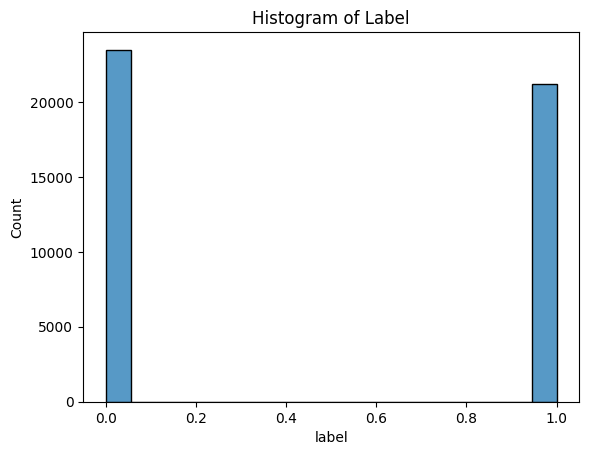

In [ ]:
#A histogram is used to visualize the frequency distribution of categorical variables like label.

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(news_df["label"])

plt.title("Histogram of Label")
plt.show()

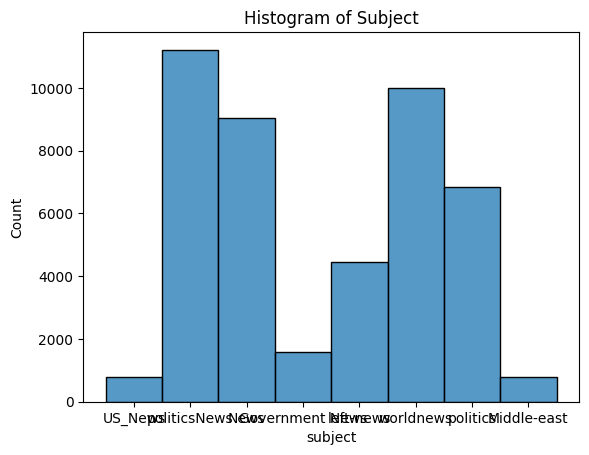

In [ ]:
#A histogram is used to visualize the frequency distribution of categorical variables like label.
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(news_df["subject"])

plt.title("Histogram of Subject")
plt.show()

##### REMOVING URLS FROM THE DATA 

In [ ]:
# we will check how many URLs are present in the data
import re

url_pattern = r'https?://\S+|www\.\S+'

total_urls = news_df["text"].astype(str).apply(
    lambda x: len(re.findall(url_pattern, x))
).sum()

print("Total URLs in dataset:", total_urls)

Total URLs in dataset: 4784


In [ ]:
# We are removing the Urls from the data 

news_df["text"] = news_df["text"].astype(str).apply(
    lambda x: re.sub(url_pattern, '', x)
)

In [ ]:
# checking the data that all the Urls have been removed or not 
remaining_urls = news_df["text"].astype(str).str.contains(url_pattern, regex=True).sum()

print("Remaining URLs:", remaining_urls)

Remaining URLs: 0


In [ ]:
import re

##### TEXT PROCESSING - Convert to String ,Keep Only Alphabets,Convert to Lowercase,Tokenization

In [ ]:
# This cleans raw news text and converts it into tokens (words) for NLP,ML models and word2 vec

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z]", " ", text)      # keep only alphabets
    text = text.lower()
    return text.split()  # return tokens

##### VECTORIZED FUNCTION MAPPING

In [ ]:
#This step applies the text preprocessing function to every news article and converts the text into tokens for Word2Vec training.

In [ ]:
news_df["tokens"] = news_df["content"].map(clean_text)

##### WORD EMBEDDING TRANNING USING W2V

In [ ]:
#It trains a Word2Vec model that converts words into numerical vectors to make machine understand  

In [ ]:
from gensim.models import Word2Vec   

In [ ]:
w2v_model = Word2Vec(
    sentences=news_df["tokens"],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

##### Converting Text Documents into Feature Vectors  || Document Vectorization using Average Word2Vec

In [ ]:
def get_average_vector(tokens):    #This function converts one article (list of words) into one vector.
    vectors = []                    #We store word vectors here.
     
    for word in tokens:             #Check if Word2Vec knows it
        if word in w2v_model.wv:     #Get its 100-dimensional vector
            vectors.append(w2v_model.wv[word])  #Add it to the list
    
    if len(vectors) == 0:     # If no valid words exist:
        return np.zeros(100)   #then return this 
    
    return np.mean(vectors, axis=0)  #It will take Average of all word vectors.

X = np.array(news_df["tokens"].map(get_average_vector).tolist())  #Applies function to every article 
y = news_df["label"]  #Converts entire dataset into numeric format || Creates X (features) & Creates y (labels)

##### Train Test Spliting

In [ ]:
#This step divides the dataset into training and testing sets so the model can learn from one part and be evaluated on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

##### Model Training and Evaluation using SVM

In [ ]:
#This step trains a linear SVM classifier on the training data and evaluates its performance on test data using accuracy and classification metrics.

In [ ]:
from sklearn.svm import SVC          #Support vector classifier 
from sklearn.metrics import accuracy_score, classification_report # Calculates accuracy & Shows precision, recall, F1-score re
svm_model = SVC(kernel='linear')     # Step 1: Create model
svm_model.fit(X_train, y_train)      # Step 2: Train model
y_pred = svm_model.predict(X_test)   # Step 3: Predict
print("Accuracy:", accuracy_score(y_test, y_pred))# Step 4: Evaluate
print(classification_report(y_test, y_pred))

Accuracy: 0.9715820093980756
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4652
           1       0.97      0.97      0.97      4286

    accuracy                           0.97      8938
   macro avg       0.97      0.97      0.97      8938
weighted avg       0.97      0.97      0.97      8938



##### Model Serialization using Pickle

In [ ]:
# This step saves the trained Word2Vec and SVM models into pickle files so they can be reused later without retraining.

In [ ]:
import pickle

In [ ]:
pickle.dump(w2v_model, open("w2v_model.pkl", "wb"))
pickle.dump(svm_model, open("svm_model.pkl", "wb"))

##### Model Loading and Inference (Prediction)

In [ ]:
#This step loads the saved models, preprocesses new input text, converts it into a Word2Vec vector, and uses the trained SVM model to predict whether the news is fake or real.

In [ ]:
# Load models
w2v_loaded = pickle.load(open("w2v_model.pkl", "rb"))
svm_loaded = pickle.load(open("svm_model.pkl", "rb"))

# Sample text
sample_text = 'Trump drops Steve Bannon from National Security Council WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chiefs of Staff and Dan Coats, the director of National Intelligence who heads all 17 U.S. intelligence agencies. The official said the change moves the NSC “back to its core function of what it’s supposed to do.” It also appears to mark a victory for national security adviser H.R. McMaster, who had told some national security experts he felt he was in a “battle to the death” with Bannon and others on the White House staff. Vice President Mike Pence said Bannon would continue to play an important role in policy and played down the shake-up as routine. “This is just a natural evolution to ensure the National Security Council is organized in a way that best serves the president in resolving and making those difficult decisions,” Pence said on Fox News.  Bannon said in a statement he had succeeded in returning the NSC back to its traditional role of coordinating foreign policy rather than running it. He cited President Barack Obama’s national security adviser, Susan Rice, for why he advocated a change. “Susan Rice operationalized the NSC during the last administration so I was put on NSC to ensure it was ‘de-operationalized.’ General McMaster has NSC back to its proper function,” he said. Trump’s White House team has grappled with infighting and intrigue that has hobbled his young presidency. In recent days, several other senior U.S. foreign policy and national security officials have said the mechanisms for shaping the Trump administration’s response to pressing challenges such as Syria, North Korea and Iran still were not in place.  Critics of Bannon’s role on the NSC said it gave too much weight in decision-making to someone who lacked foreign policy expertise. Bannon, who was chief executive of Trump’s presidential campaign in the months leading to his election in November, in some respects represents Trump’s “America First” nationalistic voice, helping fuel his anti-Washington fervor and pushing for the president to part ways at times with mainstream Republicans. Before joining the Trump administration, Bannon headed Breitbart News, a right-wing website. U.S. Representative Adam Schiff, ranking Democrat on the House of Representatives Intelligence Committee, called the shift in the NSC a positive step that will help McMaster “gain control over a body that was being politicized by Bannon’s involvement.” “As the administration’s policy over North Korea, China, Russia and Syria continues to drift, we can only hope this shake-up brings some level of strategic vision to the body,” he said. Bannon’s removal from the NSC was a potential setback for his sphere of influence in the Trump White House, where he has a voice in most major decisions. But a Trump confidant said Bannon remained as influential as ever. “He is still involved in everything and still has the full confidence of the president but to be fair he can only do so much stuff,” the confidant said, speaking on condition of anonymity. The White House official said Bannon was no longer needed on the NSC after the departure of Trump’s first national security adviser, Michael Flynn. Flynn was forced to resign on Feb. 13 over his contacts with Russia’s ambassador to the United States, Sergei Kislyak, prior to Trump taking office on Jan. 20. The official said Bannon had been placed on the NSC originally as a check on Flynn and had only attended one of the NSC’s regular meetings. The official dismissed questions about a power struggle between Bannon and McMaster, saying they shared the same world view. However, two current national security officials rejected the White House explanation, noting that two months have passed since Flynn’s departure. McMaster, they said, speaking on the condition of anonymity, also has dueled with Bannon and others over direct access to Trump; the future of deputy national security adviser K.T. McFarland, a former Fox News commentator; intelligence director Ezra Cohen-Watnick, a Flynn appointee; and other staffing decisions. Trump is preparing for his first face-to-face meeting on Thursday and Friday with Chinese President Xi Jinping with the threat of North Korea’s nuclear and missile programs a key component of their talks. Bannon’s seat on the NSC’s “principals’ committee,” a group that includes the secretaries of state, defense and other ranking aides, was taken by Rick Perry, who as energy secretary is charged with overseeing the U.S. nuclear weapons arsenal. '


# Clean sample
tokens = clean_text(sample_text)

# Convert to vector
sample_vector = get_average_vector(tokens).reshape(1, -1)

# Predict
prediction = svm_loaded.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: 1
